# Interpretting "Concave-Down" Hammett Plots

It is simple to make a mathematical model for a "concave-up" Hammett plot. We simply add the rates of the two routes to product together. If a rate is more than ten times faster than the other, it will dominate the plot and we will easily be able to fit both regions of the plot to the single equation.

If the observed rate of the reaction is the result of two consecutive steps and we see the rates of each change such that the rate-determining step changes, then we may observe a "concave-down" line shape in the Hammett plot. I could not imiaging how to model a switch in the *rds* and so have always dealt with this by piecewise fitting. Use the data that is clearly in one regime to determine the reaction constant for that *rds* and do the same for the other regime. You will see that method used in many of the data sets in this course where we observe a "concave-down" Hammett plot.

## A Mathematical Model, at Last
One day I just asked ChatGPT the question "How do I fit a concave-down Hammett plot" and it provided and answer that I should have thought of myself. We can model the "concave-down" line shape using the steady-state assumption.

The steady-state method encompasses the general case for a two-step reaction with a reactive intermediate. Imagine the following reaction scheme:

\begin{equation*}
 A \;\overset{k_1}{\underset{k_{-1}}{\rightleftharpoons}}\; B \;\overset{k_2}{\longrightarrow}\; C 
\end{equation*}

We obtain a rate law of:

\begin{equation*}
 \frac{dP}{dt}=\frac{k_1 k_2}{k_{-1}+k_2}\left[A\right]
\end{equation*}



In [1]:
####################################################
### Import Libraries and set up global variables ###
####################################################

# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

try:                  # if the package exists import it, otherwise install it
    import sklearn
except ImportError:
    !pip -q install scikit-learn
    import sklearn

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M14_ExampleExplorations/data.zip
    !unzip -q data.zip

github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"

plt.rcdefaults()

#################################################################
### Global Variable                                           ###
#################################################################

sigmatype = "sigma"    # change to "sigma", "s_plus", or "s_minus"



###################################################################
### a function to fill in sigma for empty spaces in s+ and s-   ###
###################################################################

def fill_sigma(df):     
    for z in df.index:
        if np.isnan(df.loc[z,"s_plus"]):
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]
        if np.isnan(df["s_minus"][z]):
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]
    return(df)


################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

#LFER_file = "LFER_HanschLeoTaft.csv"
LFER_file = "LFER_Williams.csv"

data_set = pd.read_csv(github_location_LFER_tables + LFER_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 


########################################################
### Fill across sigma values and select substituents ###
########################################################

data_set=fill_sigma(data_set)

### Remove unneeded columns
if LFER_file == "LFER_HanschLeoTaft.csv":
    data_set.drop(labels = ["TABLE V", "TABLE I"],      #Trim "LFER_HanschLeoTaft.csv" data
    axis = 1,
    inplace = True)
elif LFER_file == "LFER_Williams.csv":
    data_set.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
    axis = 1,
    inplace = True)
else:
    print("ERROR: No filename")


################################################################################
### Read table 1 data. The fields are separated by commas; comments are enabled  ###
################################################################################

data_file = "data/ImineHydrolysis.csv"
#data_file = "Nitrosamine.csv"

table_data_df = pd.read_csv(data_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 

### Join the two dataframes according to the index column (Substituent)
df = pd.concat([table_data_df, data_set], axis=1, join="inner")

df.sort_values(by=[sigmatype], inplace=True)    # sort according to sigma so we can pick the left-most and right-most points more easily

df["logk"] = np.log10(df["k"] * 10**-5)


display(df)


,k,sigma,s_plus,s_minus,logk
Substituent,,,,,
p-OCH3,4.07,-0.27,-0.78,-0.26,-4.390406
p-CH3,7.76,-0.14,-0.31,-0.17,-4.110138
m-CH3,8.71,-0.06,-0.06,-0.06,-4.059982
H,12.59,0.00,0.00,0.00,-3.899974
m-OCH3,14.79,0.11,0.11,0.11,-3.830032
p-Cl,12.02,0.23,0.11,0.19,-3.920096
m-Cl,13.49,0.37,0.37,0.37,-3.869988
m-NO2,7.08,0.72,0.72,0.72,-4.149967


In [79]:
import lmfit

def model(sigma, A, rho1, B, rho2):
    return (
        A
        + rho1*sigma
        + np.log10(
            10**(rho2*sigma) /
            (1 + B*10**(rho2*sigma))
        )
    )


def model2(sigma, A, rho1, B, rho2):
    return (np.log10(
        10**(A + rho1*sigma) * 10**(B + rho2*sigma) / 
        ( 10**(A + rho1*sigma) +10**(B + rho2*sigma))
    ))

x = df[sigmatype].to_numpy()
y = df["logk"].to_numpy()


mod = lmfit.Model(model2)

params = mod.make_params(
    A = dict(
        value = -4,      # setting an initial guess. This is not necessary but can help in complex cases.
        min = -5,        # set a minimum value for the parameter
        max = -3,         # set a maximum value for the parameter
        vary = True,    # allow the parameter to vary in the optimization
    ),
    rho1 = dict(       # 
        value = 2.5,      # set A_inf to zero
        min = 1,        # set a minimum value for the parameter
        max = 3.5,         # set a maximum value for the parameter
        vary = True,    # allow the parameter to vary in the optimization
    ), 
    B =  dict(
        value = -3.6, 
        min = -5,        # set a minimum value for the parameter
        max = -2,         # set a maximum value for the parameter
        vary = True,    # allow the parameter to vary in the optimization
   ),
    rho2 =  dict(
        value = -.75, 
        min = -1,        # set a minimum value for the parameter
        max = -0.5,         # set a maximum value for the parameter
        vary = True,    # allow the parameter to vary in the optimization
   ),
)

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, params, sigma=x, 
                 #nan_policy='omit',
                 #method='least_squares'
                 ) 

print(result.fit_report())
print()
#print(result.ci_report())



params = np.array(list(result.params.valuesdict().values()))



[[Model]]
    Model(model2)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 8
    # variables        = 4
    chi-square         = 0.01139232
    reduced chi-square = 0.00284808
    Akaike info crit   = -44.4340614
    Bayesian info crit = -44.1162952
    R-squared          = 0.95372193
[[Variables]]
    A:    -3.66531912 +/- 0.13948496 (3.81%) (init = -4)
    rho1:  2.50455052 +/- 0.55240304 (22.06%) (init = 2.5)
    B:    -3.60068297 +/- 0.12870081 (3.57%) (init = -3.6)
    rho2: -0.75185645 +/- 0.21690357 (28.85%) (init = -0.75)
[[Correlations]] (unreported correlations are < 0.100)
    C(B, rho2)    = -0.9515
    C(A, rho1)    = +0.9335
    C(A, B)       = -0.9228
    C(A, rho2)    = +0.8561
    C(rho1, B)    = -0.8437
    C(rho1, rho2) = +0.7643



In [78]:
3.25640892-0.75185591

2.5045530100000004

In [69]:
params, cov = curve_fit(model, x, y)
params

array([-3.66531857, -0.75185591,  0.86171726,  3.25640892])

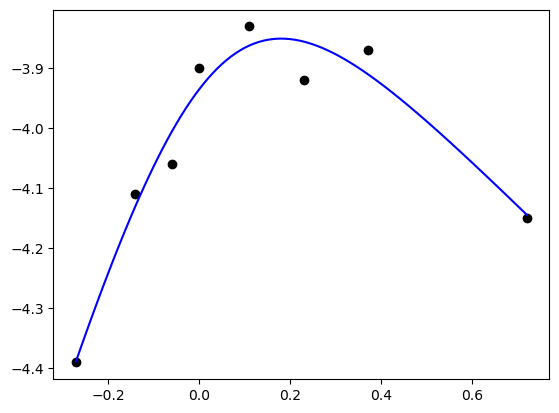

In [80]:
plt.scatter(x, y, label="Data", color="black")
xfit = np.linspace(min(x), max(x), 100)
yfit = model2(xfit, *params)
plt.plot(xfit, yfit, label="Fit", color="blue")

In [73]:
def model(sigma, A, rho2, B, rhoK):
    return (
        A
        + rho2*sigma
        + np.log10(
            10**(rhoK*sigma) /
            (1 + B*10**(rhoK*sigma))
        )
    )

x = df[sigmatype].to_numpy()
y = df["logk"].to_numpy()


popt, pcov = curve_fit(model, x, y)
popt

array([-3.66531857, -0.75185591,  0.86171726,  3.25640892])

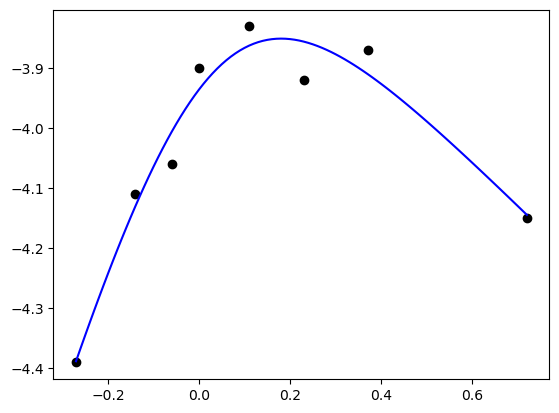

In [76]:
plt.scatter(x, y, label="Data", color="black")
xfit = np.linspace(min(x), max(x), 100)
yfit = model(xfit, *popt)
plt.plot(xfit, yfit, label="Fit", color="blue")